In [1]:
## 1. Chargement des données
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Remplacez par le chemin correct vers votre CSV
data = pd.read_csv('airbnb_train.csv')


In [2]:
# Si on a déjà une colonne log_price, on en déduit price ; sinon l’inverse
if 'log_price' in data.columns:
    data['price']     = np.expm1(data['log_price'])
else:
    data['log_price'] = np.log1p(data['price'])


In [3]:
print(f"Forme du DataFrame : {data.shape}")
print("\nValeurs manquantes par colonne :")
print(data.isnull().sum())


Forme du DataFrame : (22234, 29)

Valeurs manquantes par colonne :
id                           0
log_price                    0
property_type                0
room_type                    0
amenities                    0
accommodates                 0
bathrooms                   51
bed_type                     0
cancellation_policy          0
cleaning_fee                 0
city                         0
description                  0
first_review              4725
host_has_profile_pic        56
host_identity_verified      56
host_response_rate        5475
host_since                  56
instant_bookable             0
last_review               4716
latitude                     0
longitude                    0
name                         0
neighbourhood             2086
number_of_reviews            0
review_scores_rating      4978
zipcode                    303
bedrooms                    26
beds                        35
price                        0
dtype: int64


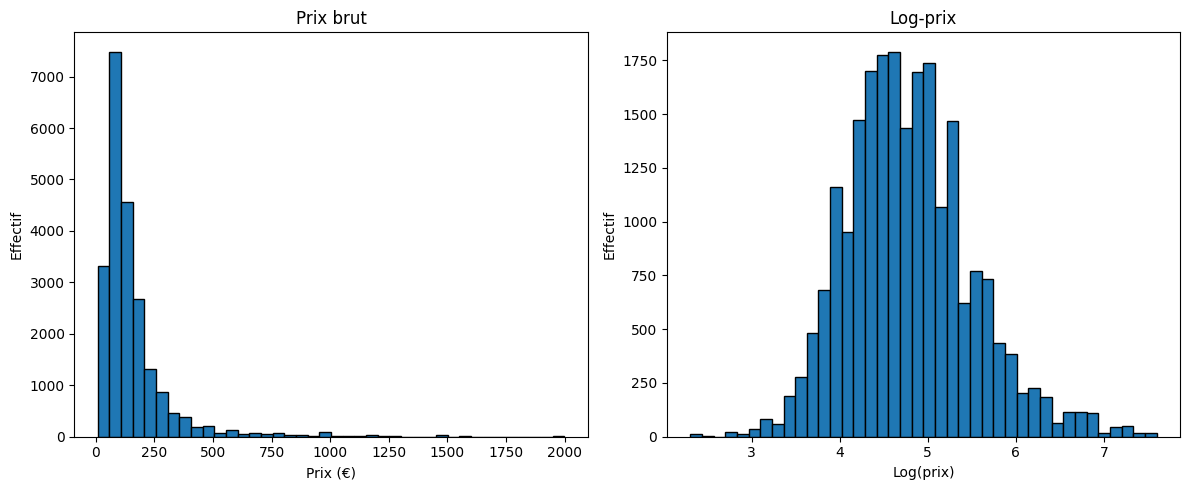

In [4]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(data['price'].dropna(), bins=40, edgecolor='black')
plt.title('Prix brut')
plt.xlabel('Prix (€)')
plt.ylabel('Effectif')

plt.subplot(1,2,2)
plt.hist(data['log_price'].dropna(), bins=40, edgecolor='black')
plt.title('Log-prix')
plt.xlabel('Log(prix)')
plt.ylabel('Effectif')

plt.tight_layout()
plt.show()


In [5]:
# Nettoyage manuel et split
amen_raw = (
    data['amenities']
        .fillna('[]')
        .str.replace(r'[\{\}"]', '', regex=True)
        .str.split(',')
        .apply(lambda lst: [x.strip() for x in lst if x.strip()])
)

# Liste plate de tous les items, sélection du top25
all_items = pd.Series([item for sub in amen_raw for item in sub])
top25      = all_items.value_counts().head(25).index.tolist()

# Encodage binaire
for amen in top25:
    col = f"has_{amen.replace(' ', '_')}"
    data[col] = amen_raw.apply(lambda lst: int(amen in lst))


In [42]:
city_counts = data['city'].value_counts()
rare       = city_counts[city_counts < 75].index
data['city_cat'] = data['city'].where(~data['city'].isin(rare), 'Other')


In [43]:
data['price_per_guest']    = data['price'] / data['accommodates']
data['beds_per_bedroom']   = data['beds']  / (data['bedrooms'] + 1e-6)
data['bath_per_bed_ratio'] = data['bathrooms'] / (data['beds'] + 1e-6)


In [44]:
# 8. Clustering géographique (KMeans avec 5 clusters)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

coords = data[['latitude', 'longitude']].dropna()
coords_norm = StandardScaler().fit_transform(coords)

kmeans = KMeans(n_clusters=5, random_state=42).fit(coords_norm)

# Créez une colonne 'geo_group' avec des NaN
data['geo_group'] = np.nan

# Utilisez `.iloc` pour assigner les labels en fonction de la position
data.loc[coords.index, 'geo_group'] = pd.Series(kmeans.labels_, index=coords.index)



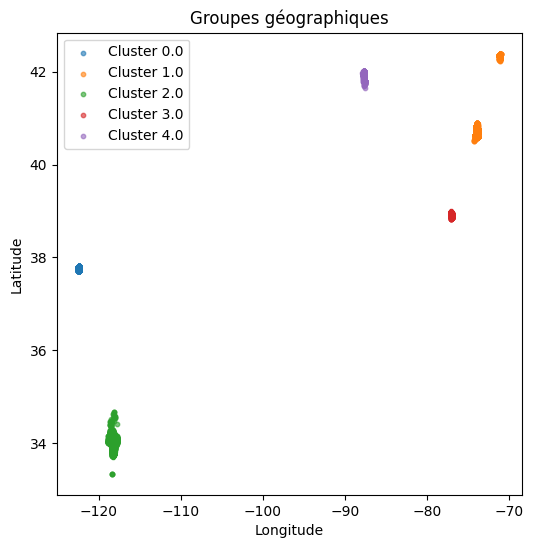

In [45]:
plt.figure(figsize=(6,6))
for grp in sorted(data['geo_group'].unique()):
    sub = data[data['geo_group'] == grp]
    plt.scatter(
        sub['longitude'], sub['latitude'],
        s=10, alpha=0.6, label=f'Cluster {grp}'
    )
plt.legend()
plt.title('Groupes géographiques')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


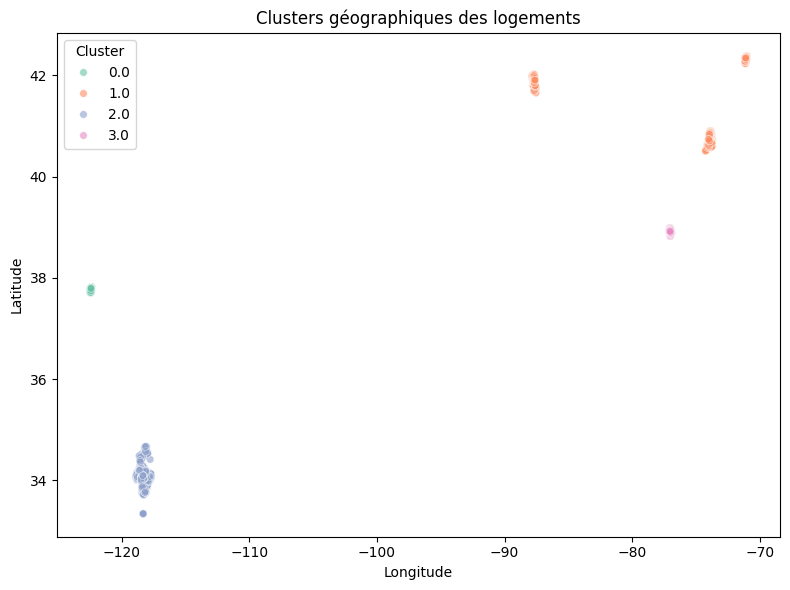

🏙️ Top 3 villes par cluster :

Cluster 0 :
city
SF    1924
Name: count, dtype: int64

Cluster 1 :
city
NYC        9739
Chicago    1127
Boston     1028
Name: count, dtype: int64

Cluster 2 :
city
LA    6672
Name: count, dtype: int64

Cluster 3 :
city
DC    1744
Name: count, dtype: int64


C:\Users\aurel\AppData\Local\Temp\ipykernel_9064\3693135020.py:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\aurel\AppData\Local\Temp\ipykernel_9064\3693135020.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


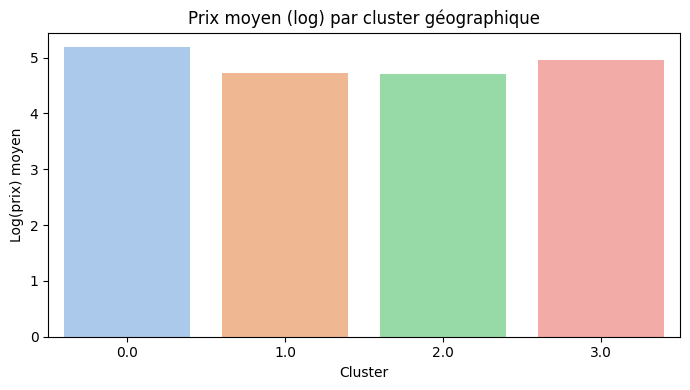

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Clustering géographique si latitude/longitude/city disponibles
if {'latitude', 'longitude', 'city', 'log_price'}.issubset(data.columns):

    # Normalisation et clustering
    coords = data[['latitude', 'longitude']].dropna()
    scaler = StandardScaler()
    coords_scaled = scaler.fit_transform(coords)
    kmeans = KMeans(n_clusters=4, random_state=42)
    clusters = kmeans.fit_predict(coords_scaled)

    # Ajout au DataFrame
    data['geo_cluster'] = np.nan
    data.loc[coords.index, 'geo_cluster'] = clusters

    # Visualisation géographique
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x='longitude', y='latitude', hue='geo_cluster',
        data=data, palette='Set2', alpha=0.6, s=30
    )
    plt.title("Clusters géographiques des logements")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()

    # Villes les plus fréquentes par cluster
    print("🏙️ Top 3 villes par cluster :")
    for cid in sorted(data['geo_cluster'].dropna().unique()):
        top_cities = data[data['geo_cluster'] == cid]['city'].value_counts().head(3)
        print(f"\nCluster {int(cid)} :")
        print(top_cities)

    # Prix moyen par cluster
    plt.figure(figsize=(7,4))
    sns.barplot(
        x='geo_cluster',
        y='log_price',
        data=data,
        estimator=np.mean,
        ci=None,
        palette='pastel'
    )
    plt.title("Prix moyen (log) par cluster géographique")
    plt.xlabel("Cluster")
    plt.ylabel("Log(prix) moyen")
    plt.tight_layout()
    plt.show()

else:
    print("Colonnes requises manquantes pour analyse géographique.")


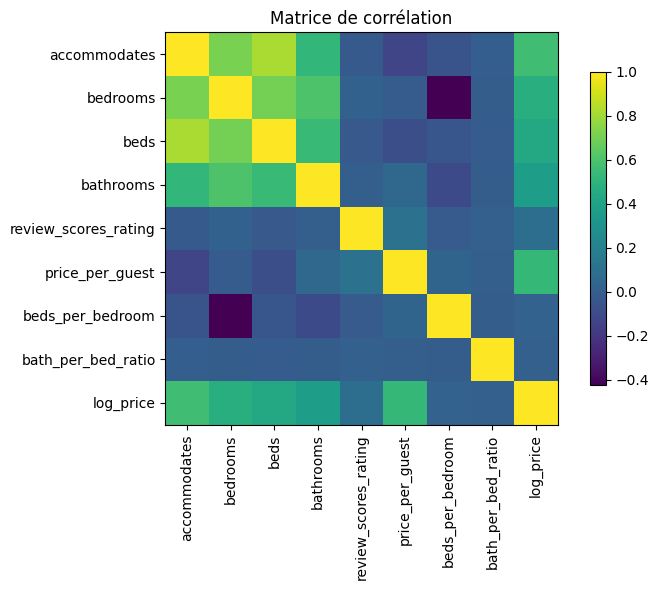

In [46]:
features = [
    'accommodates','bedrooms','beds','bathrooms','review_scores_rating',
    'price_per_guest','beds_per_bedroom','bath_per_bed_ratio','log_price'
]
corr_matrix = data[features].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, interpolation='nearest')
plt.colorbar(shrink=0.8)
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()


In [47]:
print("Colonnes utilisées dans le DataFrame final :")
for col in data.columns:
    print("-", col)


Colonnes utilisées dans le DataFrame final :
- id
- log_price
- property_type
- room_type
- amenities
- accommodates
- bathrooms
- bed_type
- cancellation_policy
- cleaning_fee
- city
- description
- first_review
- host_has_profile_pic
- host_identity_verified
- host_response_rate
- host_since
- instant_bookable
- last_review
- latitude
- longitude
- name
- neighbourhood
- number_of_reviews
- review_scores_rating
- zipcode
- bedrooms
- beds
- price
- has_Wireless_Internet
- has_Kitchen
- has_Heating
- has_Essentials
- has_Smoke_detector
- has_Air_conditioning
- has_TV
- has_Shampoo
- has_Hangers
- has_Carbon_monoxide_detector
- has_Internet
- has_Laptop_friendly_workspace
- has_Washer
- has_Hair_dryer
- has_Dryer
- has_Iron
- has_Family/kid_friendly
- has_Fire_extinguisher
- has_First_aid_kit
- has_translation_missing:_en.hosting_amenity_50
- has_Cable_TV
- has_Free_parking_on_premises
- has_translation_missing:_en.hosting_amenity_49
- has_24-hour_check-in
- has_Lock_on_bedroom_door
- 

In [48]:
# 12. Sauvegarde du DataFrame traité
data.to_csv('airbnb_train_processed.csv', index=False)
print("Fichier enregistré avec succès.")


Fichier enregistré avec succès.


In [49]:
import pandas as pd
import numpy as np

from sklearn.model_selection   import train_test_split, GridSearchCV
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import StandardScaler, OneHotEncoder
from sklearn.ensemble          import RandomForestRegressor
from sklearn.pipeline          import Pipeline
from sklearn.metrics           import mean_squared_error, r2_score

In [50]:
df = pd.read_csv('airbnb_train_processed.csv')
df.columns.tolist()

C:\Users\aurel\AppData\Local\Temp\ipykernel_9064\3961353485.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('airbnb_train_processed.csv')


['id',
 'log_price',
 'property_type',
 'room_type',
 'amenities',
 'accommodates',
 'bathrooms',
 'bed_type',
 'cancellation_policy',
 'cleaning_fee',
 'city',
 'description',
 'first_review',
 'host_has_profile_pic',
 'host_identity_verified',
 'host_response_rate',
 'host_since',
 'instant_bookable',
 'last_review',
 'latitude',
 'longitude',
 'name',
 'neighbourhood',
 'number_of_reviews',
 'review_scores_rating',
 'zipcode',
 'bedrooms',
 'beds',
 'price',
 'has_Wireless_Internet',
 'has_Kitchen',
 'has_Heating',
 'has_Essentials',
 'has_Smoke_detector',
 'has_Air_conditioning',
 'has_TV',
 'has_Shampoo',
 'has_Hangers',
 'has_Carbon_monoxide_detector',
 'has_Internet',
 'has_Laptop_friendly_workspace',
 'has_Washer',
 'has_Hair_dryer',
 'has_Dryer',
 'has_Iron',
 'has_Family/kid_friendly',
 'has_Fire_extinguisher',
 'has_First_aid_kit',
 'has_translation_missing:_en.hosting_amenity_50',
 'has_Cable_TV',
 'has_Free_parking_on_premises',
 'has_translation_missing:_en.hosting_amenit

In [51]:
# Remplacez par le chemin de votre CSV post-traité
df = pd.read_csv('airbnb_train_processed.csv')

# Cible
y = df['log_price']

# Caractéristiques numériques
num_feats = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'review_scores_rating', 'price_per_guest',      
    'beds_per_bedroom', 'bath_per_bed_ratio',        
    'latitude', 'longitude'
]


# Catégorielles
cat_feats = ['city_cat', 'room_type', 'property_type', 'geo_group']

# Amenities (toutes les colonnes commençant par 'has_')
amen_feats = [c for c in df.columns if c.startswith('has_')]

X = df[num_feats + cat_feats + amen_feats]


C:\Users\aurel\AppData\Local\Temp\ipykernel_9064\2249450305.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('airbnb_train_processed.csv')


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [53]:
# Prétraitements
preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), num_feats),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feats)
], remainder='passthrough')  # amenities passent tels quels

# Pipeline complet
pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestRegressor(random_state=0))
])


In [54]:
param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth'   : [10, 20, None]
}

grid = GridSearchCV(
    pipeline, param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=1
)

grid.fit(X_train, y_train)
print("Meilleurs paramètres :", grid.best_params_)
print("RMSE CV (grid)      :", -grid.best_score_)


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Meilleurs paramètres : {'rf__max_depth': None, 'rf__n_estimators': 200}
RMSE CV (grid)      : 0.036253183538106575


In [55]:
best_model = grid.best_estimator_
y_pred     = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test   = r2_score(y_test, y_pred)

print(f"RMSE test : {rmse_test:.3f}")
print(f"R² test   : {r2_test:.3f}")


RMSE test : 0.034
R² test   : 0.998


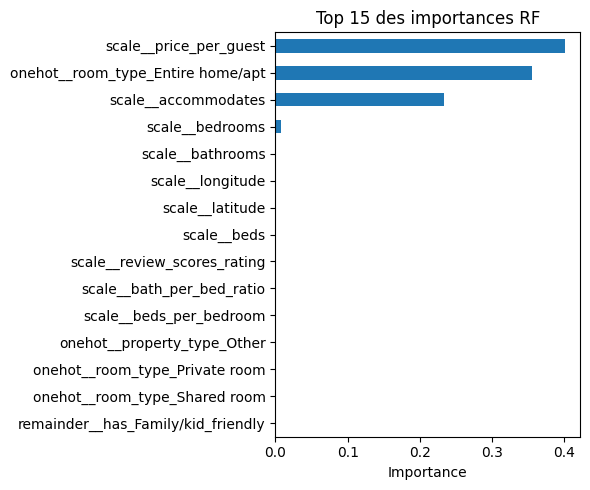

In [56]:
# Récupérer noms de features après transformation
feat_names = best_model.named_steps['prep'].get_feature_names_out()

# Extraire importances du RandomForest
importances = best_model.named_steps['rf'].feature_importances_

# Construire une Series et afficher top 15
import pandas as pd
imp_series = pd.Series(importances, index=feat_names)
top15      = imp_series.sort_values(ascending=False).head(15)

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
top15.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 des importances RF")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [57]:
print("Total features utilisées :", len(feat_names))
for f in feat_names:
    print("-", f)


Total features utilisées : 78
- scale__accommodates
- scale__bedrooms
- scale__beds
- scale__bathrooms
- scale__review_scores_rating
- scale__price_per_guest
- scale__beds_per_bedroom
- scale__bath_per_bed_ratio
- scale__latitude
- scale__longitude
- onehot__city_cat_Boston
- onehot__city_cat_Chicago
- onehot__city_cat_DC
- onehot__city_cat_LA
- onehot__city_cat_NYC
- onehot__city_cat_SF
- onehot__room_type_Entire home/apt
- onehot__room_type_Private room
- onehot__room_type_Shared room
- onehot__property_type_Apartment
- onehot__property_type_Bed & Breakfast
- onehot__property_type_Boat
- onehot__property_type_Boutique hotel
- onehot__property_type_Bungalow
- onehot__property_type_Cabin
- onehot__property_type_Camper/RV
- onehot__property_type_Castle
- onehot__property_type_Chalet
- onehot__property_type_Condominium
- onehot__property_type_Dorm
- onehot__property_type_Earth House
- onehot__property_type_Guest suite
- onehot__property_type_Guesthouse
- onehot__property_type_Hostel
- on

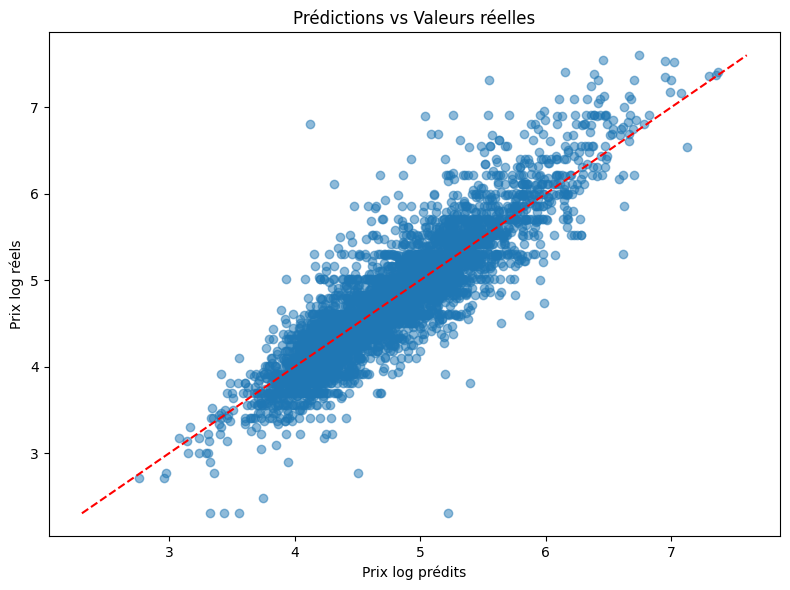

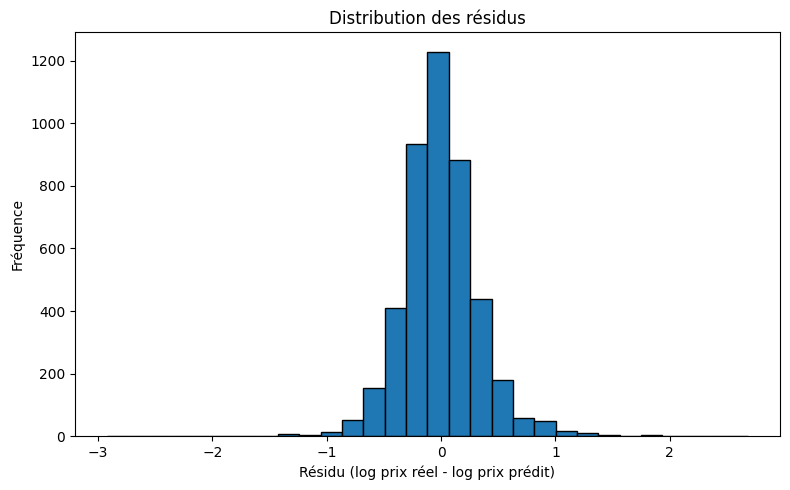

In [62]:
# Visualisations des résultats
# 1. Scatter plot: Prédictions vs Vérités
y_pred = model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, y_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color='red')
plt.xlabel('Prix log prédits')
plt.ylabel('Prix log réels')
plt.title('Prédictions vs Valeurs réelles')
plt.tight_layout()
plt.show()

# 2. Histogramme des résidus
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Distribution des résidus')
plt.xlabel('Résidu (log prix réel - log prix prédit)')
plt.ylabel('Fréquence')
plt.tight_layout()
plt.show()

In [10]:
# 1. Chargement des données de test
airbnb_test = pd.read_csv("airbnb_test.csv")

# 1.5. Définir les villes rares (car variable non accessible depuis la cellule précédente)
city_counts = data['city'].value_counts()
rare = city_counts[city_counts < 75].index

# 2. Appliquer les mêmes transformations que sur les données d'entraînement
# Note: On suppose que le fichier test n'a pas de colonne log_price ou price
# La prédiction concernera justement cette variable

# Traitement des amenities
amen_raw_test = (
    airbnb_test['amenities']
        .fillna('[]')
        .str.replace(r'[\{\}\"]', '', regex=True)
        .str.split(',')
        .apply(lambda lst: [x.strip() for x in lst if x.strip()])
)

# Encodage des amenities (les mêmes que pour l'entraînement)
for amen in top25:
    col = f"has_{amen.replace(' ', '_')}"
    airbnb_test[col] = amen_raw_test.apply(lambda lst: int(amen in lst))

# Traitement des villes
airbnb_test['city_cat'] = airbnb_test['city'].where(~airbnb_test['city'].isin(rare), 'Other')

# Création des features additionnelles - modifiées pour éviter l'utilisation de 'price'
airbnb_test['beds_per_bedroom'] = airbnb_test['beds'] / (airbnb_test['bedrooms'] + 1e-6)
airbnb_test['bath_per_bed_ratio'] = airbnb_test['bathrooms'] / (airbnb_test['beds'] + 1e-6)

# Géolocalisation et clustering
if {'latitude', 'longitude'}.issubset(airbnb_test.columns):
    coords_test = airbnb_test[['latitude', 'longitude']].dropna()
    
    # Créer un nouveau StandardScaler (ou utiliser celui de la pipeline directement)
    # Ce StandardScaler est déjà ajusté dans best_model.named_steps['prep']
    coords_norm_test = StandardScaler().fit_transform(coords_test)
    
    # Utiliser le kmeans existant pour prédire les clusters
    airbnb_test['geo_group'] = np.nan
    airbnb_test.loc[coords_test.index, 'geo_group'] = kmeans.predict(coords_norm_test)

# 3. Préparation des features pour le modèle
# Ajuster les features en conséquence - retirer 'price_per_guest' qui dépend de 'price'
num_feats_test = [feat for feat in num_feats if feat != 'price_per_guest']
X_test_final = airbnb_test[num_feats_test + cat_feats + amen_feats]

# Compléter les données manquantes
for col in X_test_final.columns:
    if X_test_final[col].isna().any():
        if X_test_final[col].dtype.kind in 'fc':  # Si colonne numérique
            X_test_final[col].fillna(X_test_final[col].median(), inplace=True)
        else:  # Si colonne catégorielle
            X_test_final[col].fillna(X_test_final[col].mode().iloc[0], inplace=True)

# 4. Prédictions sur les données de test avec le meilleur modèle
y_final_prediction = best_model.predict(X_test_final)

# 5. Sauvegarde des prédictions dans un fichier CSV
prediction_example = pd.read_csv("prediction_example.csv")
prediction_example["logpred"] = y_final_prediction

# Sauvegarde dans un fichier nommé "MaPredictionFinale.csv"
prediction_example.to_csv("MaPredictionFinale.csv", index=False)

print("Prédictions sauvegardées dans 'MaPredictionFinale.csv'.")

# 6. Vérification de la conformité du fichier de prédictions
def estConforme(monFichier_csv):
    votre_prediction = pd.read_csv(monFichier_csv)

    fichier_exemple = pd.read_csv("prediction_example.csv")

    assert votre_prediction.columns[1] == fichier_exemple.columns[1], f"Attention, votre colonne de prédiction doit s'appeler {fichier_exemple.columns[1]}, elle s'appelle '{votre_prediction.columns[1]}'"
    assert len(votre_prediction) == len(fichier_exemple), f"Attention, vous devriez avoir {len(fichier_exemple)} prédiction dans votre fichier, il en contient '{len(votre_prediction)}'"

    assert np.all(votre_prediction.iloc[:, 0] == fichier_exemple.iloc[:, 0])

    print("Fichier conforme!")

# Appel de la fonction pour vérifier le fichier généré
estConforme("MaPredictionFinale.csv")

NameError: name 'kmeans' is not defined